# Estimation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mode

In [2]:
sample = pd.Series(np.random.normal(0, 1, size=5000))
sample

0       0.284942
1      -0.135143
2      -0.776660
3       1.308496
4      -0.564349
          ...   
4995    1.229493
4996   -0.172831
4997   -0.343587
4998    1.173330
4999   -0.388324
Length: 5000, dtype: float64

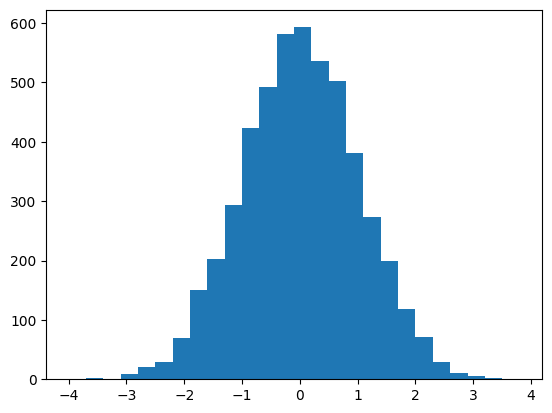

In [3]:
fig, ax = plt.subplots()
ax.hist(sample, bins=np.arange(-4, 4, 0.3))
plt.show()

In [4]:
np.mean(sample), np.std(sample)

(np.float64(0.014968016699439243), np.float64(1.005913183101135))

We didn't have to show it in graph but we can totally say that `np.random.normal` creates normally distributed numbers.

In [5]:
def make_normal_sample(mu, sigma, n):
    return np.random.normal(mu, sigma, n)

In [6]:
ns = np.logspace(1, 5).astype(int)

We are going to use these `n`s to see how the _estimator_ changes when the sample size increases.

In [7]:
mu = 3.7
sigma = 0.46

In [8]:
means = [np.mean(make_normal_sample(mu, sigma, n)) for n in ns]
medians = [np.median(make_normal_sample(mu, sigma, n)) for n in ns]

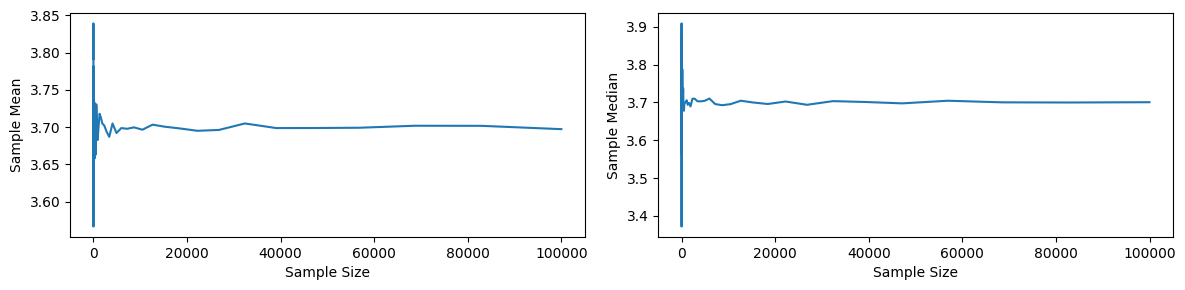

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(ns, means)
axes[1].plot(ns, medians)
axes[0].set_ylabel("Sample Mean")
axes[0].set_xlabel("Sample Size")
axes[1].set_ylabel("Sample Median")
axes[1].set_xlabel("Sample Size")
plt.tight_layout()
plt.show()

Right here, we actually visualized how WLLN (Weak Law of Large Numbers) work. We also saw that in a normal distribution, both mean and median are great estimators; because mean, median and the mode is all equal in a normal distribution. Using mean would be better in this case, since it is more efficient.

**What is an estimator?:** When we say estimator, we are actually trying to say that best estimator of the population parameter as the sample size goes to infinity, where parameter can be anything you want (SD, mean, median etc.).

Before getting in more deeper into other stuff, I just want to clear out that we are using central tendency measures right now. All of them can be useful in appropriate conditions. However, which one is more useful may depend on the answer we’re looking for. Let’s illustrate this with an example from the real world.

If we tried to visualize the histogram of the world wealth, since most of the world works for roughly the same pay, but only a few are wealthy, we would see a right-skewed distribution.

In [10]:
income = np.random.lognormal(9, 2.1, size=1_000_000)
bins = np.linspace(0, 200_000, 100)

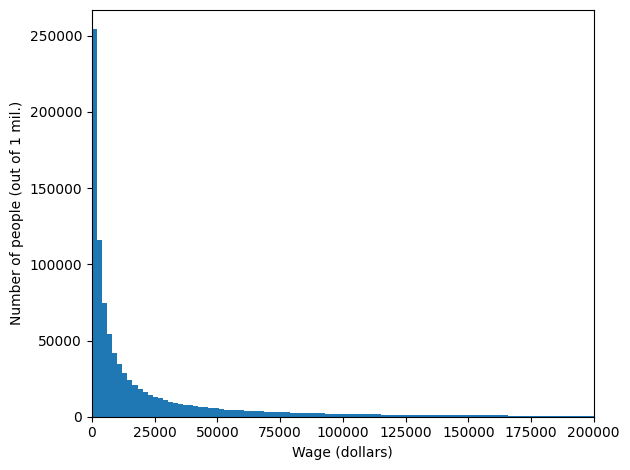

In [11]:
fig, ax = plt.subplots()
ax.hist(income, bins=bins)
ax.set_xlim(0, 200_000)
ax.set_ylabel("Number of people (out of 1 mil.)")
ax.set_xlabel("Wage (dollars)")
plt.tight_layout()
plt.show()

Let's also visualize the mean, median and the mode of this distribution.

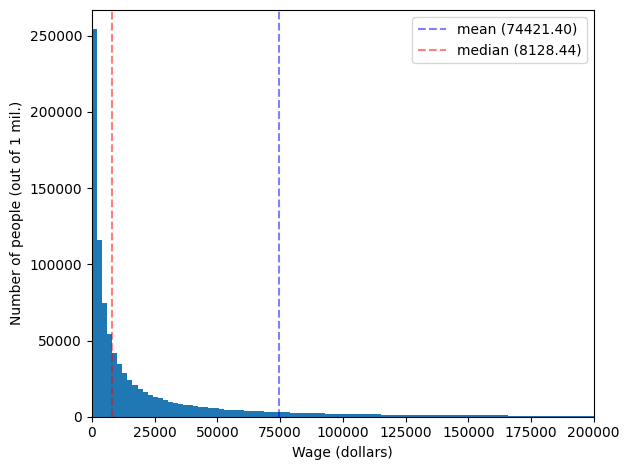

In [12]:
fig, ax = plt.subplots()
ax.hist(income, bins=bins)
ax.axvline(
    np.mean(income),
    linestyle="--",
    color="blue",
    alpha=0.5,
    label=f"mean ({np.mean(income):.2f})",
)
ax.axvline(
    np.median(income),
    linestyle="--",
    color="red",
    alpha=0.5,
    label=f"median ({np.median(income):.2f})",
)
ax.set_xlim(0, 200_000)
ax.set_ylabel("Number of people (out of 1 mil.)")
ax.set_xlabel("Wage (dollars)")
ax.legend()
plt.tight_layout()
plt.show()

So comparing the mean and the median, which one would be closer to the answer we would get if we asked people about their wages? It would probably be the median value. Because the mean is very sensitive to outliers, and we have ultra-rich people in the distribution, we cannot rely on it.

So what does this have to do with estimation? Nothing. I just wanted to make it clearer that the fact we can obtain the same result using both the mean and the median above is a property of the normal distribution. Let's keep going with the estmiation.